#COMP 4211 PA1

##Part 0: Import Modules

###Q0: Import Modules

In [ ]:
##################
# Import modules #
##################
# Utilities
import time

# Data manipulation
import numpy as np
import pandas as pd

# Graph plotting
from matplotlib import pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import t

# scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc

##Part 1: Data Exploration and Preparation

###Q1: Load and Merge Data

In [ ]:
###############################
# Check if using google colab #
###############################
def adapt_colab_env():
  try:
    # Mount
    from google.colab import drive
    drive.mount("/content/drive")

    # Change current working directory
    from os import chdir
    #chdir("./drive/MyDrive")
    chdir("/content/drive/MyDrive/Colab Notebooks/COMP4211/pa1")
  except:
    pass

#######################
# Load and merge data #
#######################
def load_and_merge_data():
  # Load and drop duplicates of training data (part 2)
  df = pd.read_json("train_p2.json")
  df = df.drop_duplicates()

  # Merge remaining training data (part 1 & 3) into the DataFrame with sorting
  df = df.merge(pd.read_csv("train_p1.txt", delimiter="\t"), on=["dteday", "hr"])
  df = df.merge(pd.read_csv("train_p3.csv"), on=["dteday", "hr"], sort=True)

  # Re-order the columns
  df = df[["dteday", "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed", "cnt", "uv"]]

  # Return
  return df

################
# Sanity Check #
################
def Q1_sanity_check(df):
  # Load sanity result
  df_sanity = pd.read_csv("train.csv")

  # Compare
  assert df_sanity.compare(df).empty

#################
# Main function #
#################
adapt_colab_env()
df = load_and_merge_data()
Q1_sanity_check(df)

# Show merged Dataframe on Colab
df

Mounted at /content/drive


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,uv
0,2011-01-01,winter,0,1,0,0,6,0,Clear,3.28,NaN,0.81,0.0000,16,0
1,2011-01-01,winter,0,1,1,0,6,0,Clear,2.34,35.6,0.80,0.0000,40,1
2,2011-01-01,winter,0,1,2,0,6,0,Clear,2.34,35.6,0.80,0.0000,32,0
3,2011-01-01,winter,0,1,4,0,6,0,Clear,3.28,37.4,0.75,0.0000,1,0
4,2011-01-01,winter,0,1,6,0,6,0,Clear,2.34,35.6,0.80,0.0000,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13898,2012-12-31,winter,1,12,17,0,1,1,Mist/Cloudy,4.22,37.4,0.48,0.0896,164,1
13899,2012-12-31,winter,1,12,18,0,1,1,Mist/Cloudy,4.22,35.6,0.48,0.1343,122,1
13900,2012-12-31,winter,1,12,19,0,1,1,Mist/Cloudy,4.22,33.8,0.60,0.1642,119,0
13901,2012-12-31,winter,1,12,21,0,1,1,Clear,4.22,33.8,0.60,0.1642,90,1


###Q2: Missing Values

In [ ]:
####################################
# Identification of missing values #
####################################
def report_missing_values(df):
  # Count missing values for each column
  miss = df.isna().sum()

  # Join the count and the proportion into a DataFrame
  miss_report = pd.concat([miss, miss / df.count()], axis=1)
  miss_report.columns = ["Number", "Proportion"]

  # Return
  return miss_report

report_missing_values(df)

,Number,Proportion
dteday,0,0.000000
season,0,0.000000
yr,0,0.000000
mnth,0,0.000000
hr,0,0.000000
holiday,0,0.000000
weekday,0,0.000000
workingday,0,0.000000
weathersit,0,0.000000
temp,0,0.000000


**Identification:**

Column "atemp" (Feeling temperature) has 706 missing values, and the proportion is around 5.35%.

**Potential Impact:**

Missing values increase the variance of the corresponding column of data.\
In terms of model performance, missing values reduce the accuracy of the model.

###Q3: Feature Distribution

**Distinguish between continuous and discrete variables:**

Continuous and discrete variables can be determined by Mathematical properties. Continuous variables are real numbers that are collected by measurement. On the other hand, discrete variables are mainly integers that are collected by counting.

**Identify binary, nominal and ordinal categorical features:**

Binary variables have exactly 2 categories. Nominal variables have several categories without ranking. Ordinal variables have a finite range specifying the degree.

| Feature | Description | Range | Feature type |
| - | - | - | - |
| dteday | Date of observation | 2011\-01\-01 ~ 2012\-12\-31 | Categorical, ordinal |
| season | Season | \{Winter, Spring, Summer, Fall\} | Categorical, nominal |
| yr | Year | \{0: 2011, 1: 2012\} | Categorical, binary |
| mnth | Month | 1 ~ 12 | Categorical, nominal |
| hr | Hour of the day | 0 ~ 23 | Categorical, nominal |
| holiday | Is public holiday? | \{0:no, 1: yes\} | Categorical, binary |
| weekday | Day of the week | 0 ~ 6 | Categorical, nominal |
| workingday | Is working day? | \{0:no, 1: yes\} | Categorical, binary |
| weathersit | Weather situation | \{Clear, Mist/Cloudy, Light Snow/Rain, Heavy Rain/Snow\} | Categorical, ordinal |
| temp | Temperature | ℃  | Numerical, continuous |
| atemp | Feeling temperature | ℉  | Numerical, continuous |
| hum | Humidity | % | Numerical, continuous |
| windspeed | Wind speed | | Numerical, continuous |
| uv | UV index | 0 ~ 12 | Categorical, ordinal |
| cnt | Total rental bikes | | Numerical, discrete |

In [ ]:
######################################################
# Report statistical summaries of numerical features #
######################################################
def report_numerical_feature_stat(df_num):
  df_num_des = df_num.describe()
  return df_num_des.loc[["mean", "50%", "min", "max", "std"]].rename(index={"50%": "median"})

report_numerical_feature_stat(df[["temp", "atemp", "hum", "windspeed", "cnt"]])

,temp,atemp,hum,windspeed,cnt
mean,15.040803,59.763674,0.601571,0.176518,190.577070
median,15.500000,60.800000,0.620000,0.164200,143.000000
min,-17.060000,3.200000,-2.200000,-1.100000,1.000000
max,39.000000,122.000000,1.000000,0.850700,976.000000
std,9.577205,20.439876,0.328721,0.178135,182.220507


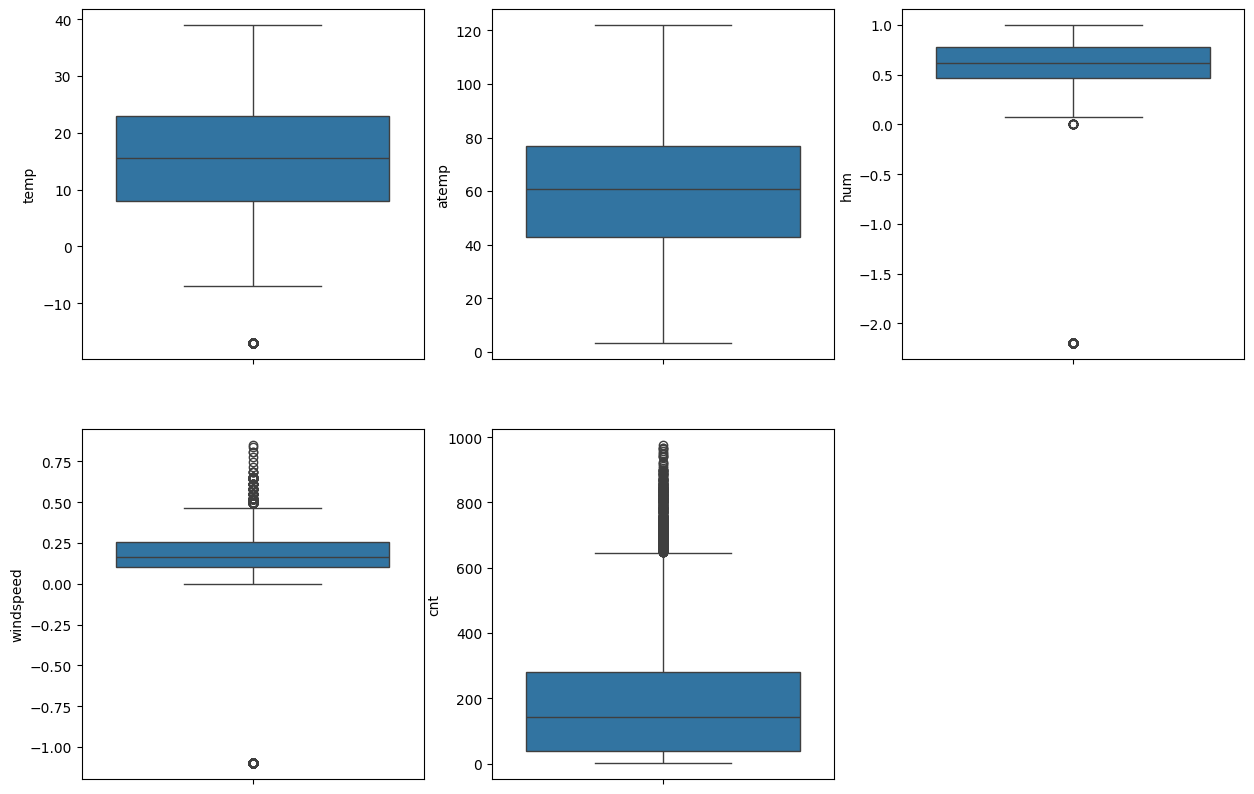

In [ ]:
######################################
# Draw boxplots of numerial features #
######################################
def draw_numerical_features_boxplot(df_num, figsize, arrangement):
  # Configure figure size
  plt.figure(figsize=figsize)

  # Draw boxplots
  for i, column_name in enumerate(df_num.columns):
    plt.subplot(*arrangement, i+1)
    sns.boxplot(df_num[column_name])

draw_numerical_features_boxplot(df[["temp", "atemp", "hum", "windspeed", "cnt"]], (15, 10), (2, 3))

season
summer    3613
spring    3512
fall      3415
winter    3363
Name: count, dtype: int64
--------------------------------------------------------------------------------
weathersit
Clear              9115
Mist/Cloudy        3655
Light Snow/Rain    1131
Heavy Rain/Snow       2
Name: count, dtype: int64
--------------------------------------------------------------------------------


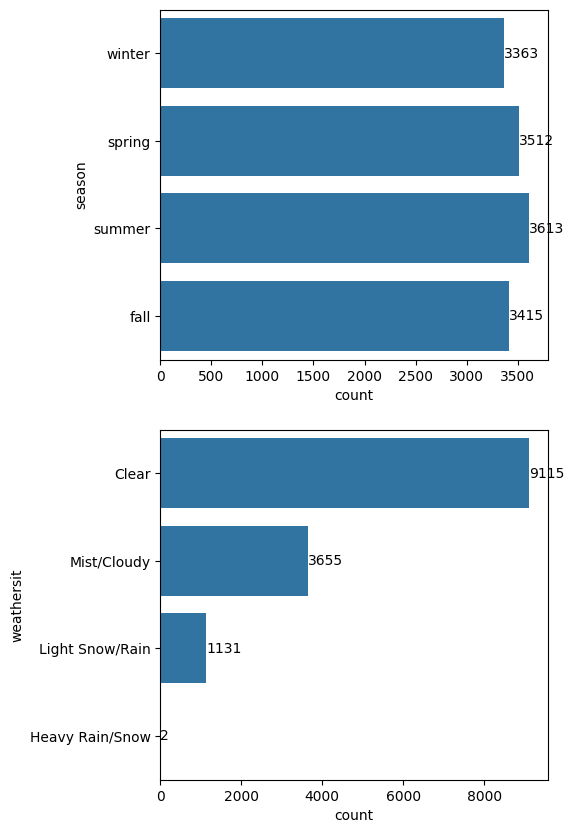

In [ ]:
def summarize_categorical_feature(df_cat):
  for column_name in df_cat.columns:
    print(df_cat[column_name].value_counts())
    print("-"*80)

###########################################
# Draw barplots of 2 categorical features #
###########################################
def draw_categorical_feature_barplot(df_cat, figsize, arrangement):
  # Configure figure size
  plt.figure(figsize=figsize)

  # Draw barplots
  for i, column_name in enumerate(df_cat.columns):
    plt.subplot(*arrangement, i+1)
    ax = sns.countplot(df_cat[column_name])
    ax.bar_label(ax.containers[0])

summarize_categorical_feature(df[["season", "weathersit"]])
draw_categorical_feature_barplot(df[["season", "weathersit"]], (5, 10), (2, 1))

###Q4: Outliers

**Detection:**

Based on the box plots in Q3, "temp", "hum", "windspeed" and "cnt" contain outliers.

In [ ]:
###############################
# Flag outliers by IQR method #
###############################
def report_outliers(df_num):
  # Find quantiles and IQR
  df_num_lq = df_num.quantile(0.25)
  df_num_uq = df_num.quantile(0.75)

  df_num_iqr = df_num_uq - df_num_lq

  # Find the bounds
  df_num_lower_bound = df_num_lq - 1.5 * df_num_iqr
  df_num_upper_bound = df_num_uq + 1.5 * df_num_iqr

  # Retrive outliers
  df_num_outliers = (df_num < df_num_lower_bound) | (df_num > df_num_upper_bound)

  # Print outliers
  for i in df_num.columns:
    print("-"*80)
    print(i)
    print(df_num[df_num_outliers[i]])

report_outliers(df[["temp", "atemp", "hum", "windspeed", "cnt"]])

--------------------------------------------------------------------------------
temp
        temp  atemp   hum  windspeed  cnt
54    -17.06   21.2  0.63     0.1343    1
75    -17.06   24.8  0.43     0.1940   88
201   -17.06   24.8  0.93     0.1045   29
335   -17.06   35.6  0.56     0.0000    5
359   -17.06   28.4  0.55     0.2537   27
...      ...    ...   ...        ...  ...
13478 -17.06   51.8  0.87     0.2836  219
13525 -17.06   35.6  0.56     0.1642    9
13611 -17.06   44.6  0.87     0.0896   87
13860 -17.06   32.0  0.79     0.1045  118
13871 -17.06   28.4  0.41     0.5821  122

[139 rows x 5 columns]
--------------------------------------------------------------------------------
atemp
Empty DataFrame
Columns: [temp, atemp, hum, windspeed, cnt]
Index: []
--------------------------------------------------------------------------------
hum
        temp  atemp  hum  windspeed  cnt
96      5.16   35.6 -2.2     0.1642   70
248     2.34   30.2 -2.2     0.1642  159
257    -0.48   30.2 -

**Consideration:**

By observation, outliers in columns "temp" and "cnt", with some of the positive "windspeeds" are extreme conditions. Those are rare yet possible to happen in real life.

In contrast, outliers in column "hum" and those nagative windspeeds are data errors since it is not possible to happen.

In preprocessing, those outliers can be substituted by the mean value of the corresponding column to reduce the impact on the model.

###B1: Grubb's Test / Hypothesis Test

Column "temp" is used in this Grubb's test since other columns' minimum values are data errors.


In [ ]:
################
# Grubbs' Test #
################
def grubbs_test(column):
  # Retrive Grubbs statistic
  grubbs_stat = (column.mean() - column.min()) / column.std()

  # Calculate the helper values
  alpha = 0.05
  n = column.shape[0]
  t_value = t.ppf(alpha / n, n - 2)

  # Calculate the critical value
  grubbs_critical = (n - 1) / n**0.5 * (t_value ** 2 / (n - 2 + t_value ** 2)) ** 0.5

  # Conclude
  print(f"""
  G:\t\t{grubbs_stat}
  G_alpha_n:\t{grubbs_critical}
  Reject H_0?:\t{grubbs_stat > grubbs_critical}
  """)

grubbs_test(df["temp"])


  G:		3.351792394716278
  G_alpha_n:	4.486360668683004
  Reject H_0?:	False
  


Based on the result of the Grubbs' test, no conclusion can be made about the minimum value selected.

###Q5: Correlation Analysis

**Feature correlation:**

<Axes: >

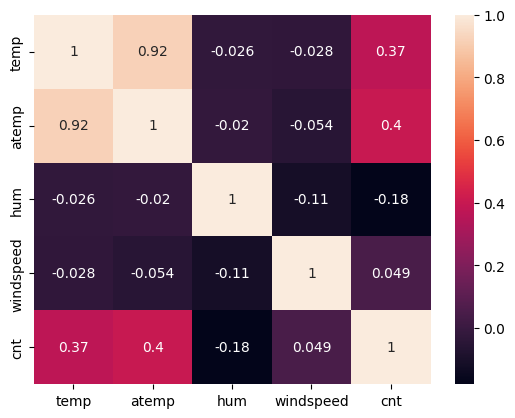

In [ ]:
####################
# Draw the heatmap #
####################
sns.heatmap(df[["temp", "atemp", "hum", "windspeed", "cnt"]].corr(), annot=True)

**Insights:**

As shown in the heatmap, columns "temp" and "atemp" have strong correlation (~0.92).

Strong correlation means the 2 features will have similar behaviours against changes, so it is not necessary to include both into the model. Moreover, putting 2 strongly correlated features into a model would lead to overfitting as the model becomes overly complex.

##Part 2: Data Preprocessing Techniques

###Q6: Handling Missing Values

In [ ]:
############################
# Missing value imputation #
############################
def impute_mean_value(df, column_name):
  # Create SimpleImputer using mean value
  imp_mean = SimpleImputer(missing_values=np.nan, strategy="mean")

  # Impute
  df[column_name] = imp_mean.fit_transform(df[[column_name]])

# Run and verify
impute_mean_value(df, "atemp")
df.isna().sum()

,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


From Q2, "atemp" is the only column with values missing.

From Q3, it is a numerical continuous feature.

From Q4, it does not have outliers.

Based on these characteristics, applying imputation by the mean value is appropriate.

**Discussion:**

Based on the impact of missing values discussed in Q2, applying imputation can reduce the variance and hence increase the model performnace. Talking about the feature distribution, it maintains a more centralized plotting.

**Judgement on imputation strategies:**

1. Mean: suitable for numerical features without extreme outliers
2. Median: similar to mean, but more useful when there are outliers
3. Mode: suitable for categorical features since the mean / median of categories is meaningless
4. Constant: similar to mode, but more appropriate when the feature has a default value

###Q7: Normalization and Standardization

In [ ]:
###########################
# Normalize / Standardize #
###########################
def norm_standardize(df):
  # Copy the dataframe
  df_norm = df.copy()

  # Applying scalers
  df_norm["temp"] = RobustScaler().fit_transform(df[["temp"]])
  df_norm["atemp"] = StandardScaler().fit_transform(df[["atemp"]])
  df_norm["hum"] = MinMaxScaler().fit_transform(df[["hum"]])
  df_norm["windspeed"] = RobustScaler().fit_transform(df[["windspeed"]])
  df_norm["cnt"] = RobustScaler().fit_transform(df[["cnt"]])

  # Return
  return df_norm

#####################
# Review statistics #
#####################
df_norm = norm_standardize(df)
df_norm[["temp","atemp","hum","windspeed","cnt"]].describe()


,temp,atemp,hum,windspeed,cnt
count,13903.000000,1.390300e+04,13903.000000,13903.000000,13903.000000
mean,-0.030532,-1.308343e-16,0.875491,0.082558,0.195790
std,0.636782,1.000036e+00,0.102725,1.193931,0.749879
min,-2.164894,-2.840485e+00,0.000000,-8.473190,-0.584362
25%,-0.500000,-8.518728e-01,0.834375,-0.400134,-0.427984
50%,0.000000,-3.568166e-16,0.881250,0.000000,0.000000
75%,0.500000,8.655648e-01,0.931250,0.599866,0.572016
max,1.562500,3.125351e+00,1.000000,4.601206,3.427984


**Comparison of scalers:**

`StandardScaler`

Standardize the data into standard normal distribution, with mean around 0 and standard deviation around 1.

Suitable for data that follows normal distribution and do not have outliers.

`MinMaxScaler`

Normalize the data into range [0, 1].

Suitable for data that need to preserve the shape of the distribution and have a finite range.

`RobustScaler`

Standardize the data without referring to the mean, but quantiles.

Suitable for data that have outliers.

**Discussion:**
Standardization / normalization can adjust the features' scales to be similar. Therefore, it can prevent a feature with a large scale to dominate the others. Besides, standardization can handle outliers, so the model performance can be improved.

###Q8: Encoding Categorical Variables

In [ ]:
##########
# Encode #
##########
def encode_df(df):
  # Copy the dataframe
  df_enc = df.copy()

  # Initialize a OneHotEncoder
  onehot_enc = OneHotEncoder(sparse_output=False)

  df_enc["dteday"] = OrdinalEncoder().fit_transform(df_enc[["dteday"]])
  df_enc[onehot_enc.get_feature_names_out(["season"])] = onehot_enc.fit_transform(df_enc[["season"]])
  # "yr" is binary. One-hot encoding is not necessary
  df_enc[onehot_enc.get_feature_names_out(["mnth"])] = onehot_enc.fit_transform(df_enc[["mnth"]])
  df_enc[onehot_enc.get_feature_names_out(["hr"])] = onehot_enc.fit_transform(df_enc[["hr"]])
  # "holiday" is binary. One-hot encoding is not necessary
  df_enc[onehot_enc.get_feature_names_out(["weekday"])] = onehot_enc.fit_transform(df_enc[["weekday"]])
  # "workingday" is binary. One-hot encoding is not necessary
  df_enc["weathersit"] = OrdinalEncoder(categories=[["Heavy Rain/Snow", "Light Snow/Rain", "Mist/Cloudy",  "Clear"]]).fit_transform(df_enc[["weathersit"]])
  df_enc["uv"] = OrdinalEncoder().fit_transform(df_enc[["uv"]])

  # Drop one-hotted columns
  df_enc = df_enc.drop(columns=["season","mnth","hr","weekday"])

  return df_enc

print(df_norm.head(10))
print("-"*80)
df_norm_enc = encode_df(df_norm)
print(df_norm_enc.head(10))

       dteday  season  yr  mnth  hr  holiday  weekday  workingday weathersit  \
0  2011-01-01  winter   0     1   0        0        6           0      Clear   
1  2011-01-01  winter   0     1   1        0        6           0      Clear   
2  2011-01-01  winter   0     1   2        0        6           0      Clear   
3  2011-01-01  winter   0     1   4        0        6           0      Clear   
4  2011-01-01  winter   0     1   6        0        6           0      Clear   
5  2011-01-01  winter   0     1   7        0        6           0      Clear   
6  2011-01-01  winter   0     1   9        0        6           0      Clear   
7  2011-01-01  winter   0     1  10        0        6           0      Clear   
8  2011-01-01  winter   0     1  11        0        6           0      Clear   
9  2011-01-01  winter   0     1  12        0        6           0      Clear   

     temp         atemp       hum  windspeed       cnt  uv  
0 -0.8125 -3.568166e-16  0.940625  -1.100536 -0.522634   0

**Judgement of encoding techniques:**

1. One-hot encoding:

Suitable for nominal features as it maintains the unordered property.

2. Ordinal encoding:

On the other hand, suitable for ordinal features as it reforms non-numerics into an ordered number sequence to align with models that only use number for computation.

###Q9: Handling Duplicate Features

In [ ]:
###########################
# Drop duplicate features #
###########################
df_dropped = df_norm_enc.drop(columns=["dteday", *[f"mnth_{i}" for i in range(1, 13)], "holiday", *[f"weekday_{i}" for i in range(7)], "temp"])
df_dropped

,yr,workingday,weathersit,atemp,hum,windspeed,cnt,uv,season_fall,season_spring,...,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
0,0,0,3.0,-3.568166e-16,0.940625,-1.100536,-0.522634,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,3.0,-1.213439e+00,0.937500,-1.100536,-0.423868,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,3.0,-1.213439e+00,0.937500,-1.100536,-0.456790,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,3.0,-1.123047e+00,0.921875,-1.100536,-0.584362,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,3.0,-1.213439e+00,0.937500,-1.100536,-0.580247,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13898,1,1,2.0,-1.123047e+00,0.837500,-0.500000,0.086420,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13899,1,1,2.0,-1.213439e+00,0.837500,-0.200402,-0.086420,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13900,1,1,2.0,-1.303830e+00,0.875000,0.000000,-0.098765,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13901,1,1,3.0,-1.303830e+00,0.875000,0.000000,-0.218107,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Duplicated columns:**

| Removed feature | Related feature\(s\) | Justification |
| - | - | - |
| dteday | yr, mnth | "dteday" is ordinal, yet it has weaker meaning since it simply grows by time. |
| mnth | season | "mnth" is nominal that needs 12 columns. Some months belongs to 2 seasons, so it does not divide the period well. |
| holiday | workingday | "workingday" is logically described by "holiday" and "weekday". |
| weekday | workingday | "workingday" is logically described by "holiday" and "weekday". |
| temp | atemp | "temp" and "atemp" are highly correlated, but "temp" has more outliers than "atemp". |

The remaining features are kept since they do not correlate with one another, and sufficiently represent information.

**Discussion:**

"temp" and "atemp" are highly correlated, the justification to consolidate them is discussed in Q5.

Keeping redundant features make the model overly complex, which is overfitting with less accuracy. Moreover, considering more information requires more computation time.

###Q10: Feature Selection

Features for target 'cnt':
Index(['yr', 'workingday', 'atemp', 'cnt', 'season_fall', 'season_spring',
       'season_summer', 'season_winter', 'hr_0', 'hr_1', 'hr_2', 'hr_3',
       'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11',
       'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19',
       'hr_20', 'hr_21', 'hr_22', 'hr_23'],
      dtype='object')
--------------------------------------------------------------------------------
Features for target 'uv':
Index(['weathersit', 'atemp', 'hum', 'uv', 'season_fall', 'season_spring',
       'season_summer', 'season_winter', 'hr_0', 'hr_1', 'hr_2', 'hr_3',
       'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11',
       'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19',
       'hr_20', 'hr_21', 'hr_22', 'hr_23'],
      dtype='object')


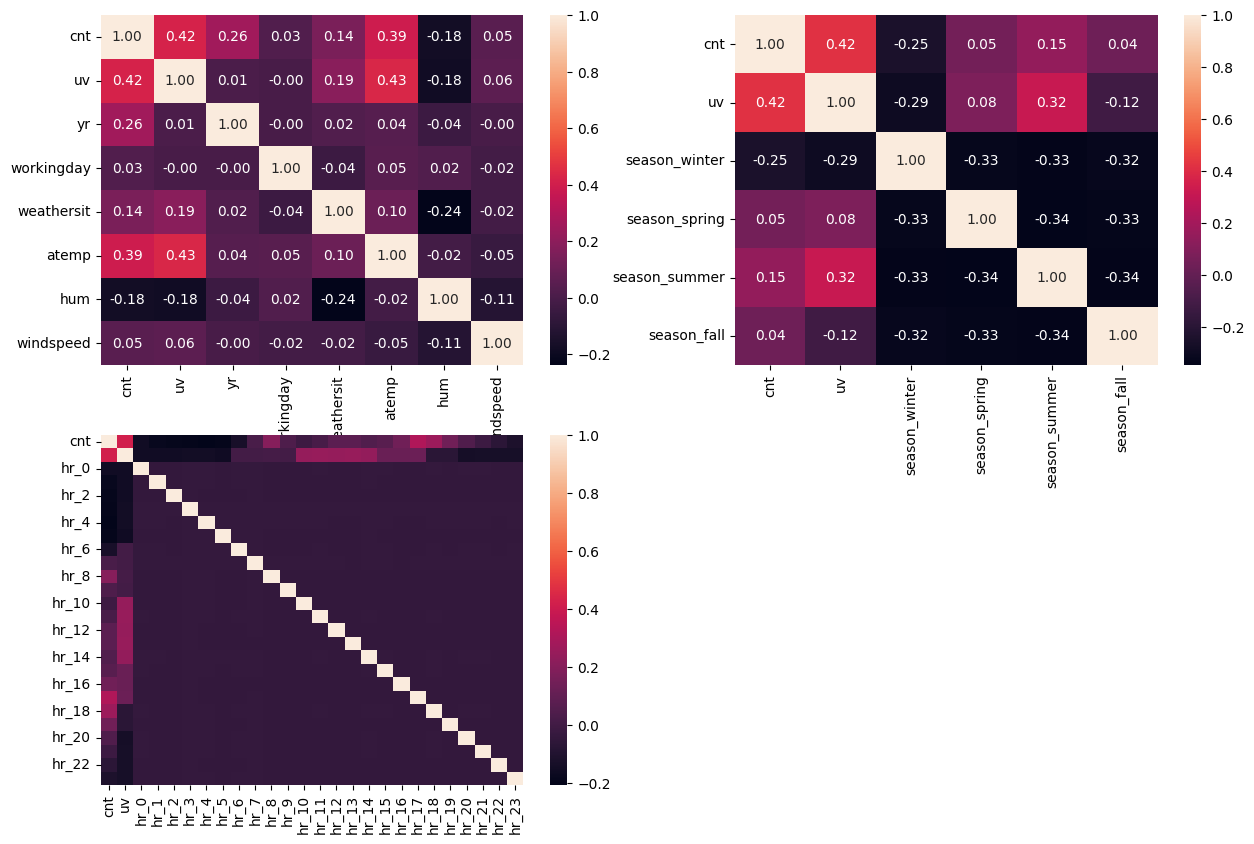

In [ ]:
##########################
# Visualize correlations #
##########################
# Configure the figure size
plt.figure(figsize=(15, 10))
feature_corr_plan = (2, 2)

# Heatmaps
plt.subplot(*feature_corr_plan, 1)
sns.heatmap(df_dropped[["cnt", "uv", "yr", "workingday", "weathersit", "atemp", "hum", "windspeed"]].corr(), annot=True, fmt=".2f")
plt.subplot(*feature_corr_plan, 2)
sns.heatmap(df_dropped[["cnt", "uv", "season_winter", "season_spring", "season_summer", "season_fall"]].corr(), annot=True, fmt=".2f")
plt.subplot(*feature_corr_plan, 3)
sns.heatmap(df_dropped[["cnt", "uv", *[f"hr_{i}" for i in range(24)]]].corr())

###################
# Select features #
###################
df_sel_cnt = df_dropped.copy().drop(columns=["hum", "weathersit", "windspeed","uv"])
df_sel_uv = df_dropped.copy().drop(columns=["yr", "workingday", "windspeed","cnt"])

print(f"Features for target 'cnt':\n{df_sel_cnt.columns}")
print("-"*80)
print(f"Features for target 'uv':\n{df_sel_uv.columns}")

**Discussion:**

Feature selection is a further step to prevent the model from overfitting. Although the information is reduced, less unrelated variables are needed to be considered so that the valuable features can contribute more in the model, and eventually increase the model performance. Besides, the model computation time can be reduced.

**Justification:**

For target "cnt":

| Removed feature | Justification |
| - | - |
| hum | Low correlation, and weather conditions are unlikely related to count |
| weathersit | Low correlation, and weather conditions are unlikely related to count |
| windspeed | Low correlation, and weather conditions are unlikely related to count |

For target "uv":

| Removed feature | Justification |
| - | - |
| yr | Low correlation, and non-periodic time is unlikely related to uv |
| workingday | Low correlation, and very short-term time is unlikely related to uv |
| windspeed | Low correlation |

##Part 3: Regression

###Q11: Train Test Split

In [ ]:
def Q11():
  # Read from csv again
  dataset = pd.read_csv("train.csv")[["yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed", "cnt"]]

  # Impute mean value if necessary
  dataset = pd.DataFrame(SimpleImputer(missing_values=np.nan, strategy="mean").fit_transform(dataset), columns=dataset.columns)

  # Train test split
  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="cnt"), dataset["cnt"], test_size=0.2, random_state=4211)

  # Train models of single feature
  for feature in X_train.columns:
    model = LinearRegression().fit(X_train[[feature]], y_train)
    print(f"R^2 score of {feature+':':11} {model.score(X_test[[feature]], y_test)}")
    print(f"MSE of {feature+':':17} {mean_squared_error(model.predict(X_test[[feature]]), y_test)}")
    print()

Q11()

R^2 score of yr:         0.07035924021112672
MSE of yr:               30991.538933405736

R^2 score of holiday:    0.0023293626980098736
MSE of holiday:          33259.45863828335

R^2 score of workingday: 0.000533717762994268
MSE of workingday:       33319.32025614825

R^2 score of temp:       0.15683051934976722
MSE of temp:             28108.83614114092

R^2 score of atemp:      0.16271062600490882
MSE of atemp:            27912.81036191757

R^2 score of hum:        0.03778783059150881
MSE of hum:              32077.37569208179

R^2 score of windspeed:  0.0011487926762032696
MSE of windspeed:        33298.81543434589



Overall, the R<sup>2</sup> scores of the single-feature models are small, and the MSE are large. This means the models do not predict well, and the relationships between the features and the target are weak.

**Relationship and difference between R<sup>2</sup> score and MSE:**

Both of the 2 metrics are measurement of a model's performance, and R<sup>2</sup> score is based on MSE by counting on the variance so that a common upper-bounded metric is formed.

Nonetheless, they are understood in different way. A good model will maximize R<sup>2</sup> score and minimize the MSE. MSE is sensitive to outliers \(the predictions with huge errors\) whereas R<sup>2</sup> score does not.

###Q12: Linear Regression Model with Multiple Features

**Mathematical meaning of the weight for a binary categorical independent variable:**

As binary categorical variables have only 2 possible values: \{0, 1\}, the weight will only work on the "True" value \(1\), i.e. when the variable is activated.

Based on this property, the weight represents how important the variable is.

Statistically, the variable is a probability to be activated. In that case, the product of the weight and the probability is the expected value of the variable.

**Formulation of independent variables from nominal categorical features:**

As the values of nominal features are unordered, one-hot encoding can be used to prevent forming implicit relationship among them. One-hot encoding will transform the values into a vector with the dimension equaling to the number of valid values. This also allows the vector to have separate weights on every entry, and eventually becomes an independent variable.

In [ ]:
def Q12():
  # Read from csv again and select features
  # "atemp": best continuous feature found
  # "hr" & "season": selected nominal categorical features in Q10
  dataset = pd.read_csv("train.csv")[["atemp", "hr", "season", "cnt"]]

  # One-hot encoding
  onehot_enc = OneHotEncoder(sparse_output=False)
  dataset[onehot_enc.get_feature_names_out(["hr"])] = onehot_enc.fit_transform(dataset[["hr"]])
  dataset[onehot_enc.get_feature_names_out(["season"])] = onehot_enc.fit_transform(dataset[["season"]])
  dataset = dataset.drop(columns=["hr", "season"])

  # Impute mean value if necessary
  dataset = pd.DataFrame(SimpleImputer().fit_transform(dataset), columns=dataset.columns)

  # Train test split
  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="cnt"), dataset["cnt"], test_size=0.2, random_state=4211)

  # Train the model
  model_linreg = LinearRegression().fit(X_train, y_train)
  print(f"R^2 score: {model_linreg.score(X_test, y_test)}")
  print(f"MSE: {mean_squared_error(model_linreg.predict(X_test), y_test)}")

Q12()

R^2 score: 0.6068177880570542
MSE: 13107.55977622985


###B2: Interpreting a regression coefficient via partialling out

In [ ]:
def B2_1():
  dataset = pd.read_csv("train.csv")[["temp", "hum", "cnt"]]

  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="cnt"), dataset["cnt"], test_size=0.2, random_state=4211)

  model = LinearRegression().fit(X_train, y_train)

  return model.coef_[1]

B2_1()

np.float64(-90.38146123603393)

In [ ]:
def B2_2():
  dataset = pd.read_csv("train.csv")[["temp", "cnt"]]

  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="cnt"), dataset["cnt"], test_size=0.2, random_state=4211)

  model = LinearRegression().fit(X_train, y_train)
  res_cnt_temp = y_train - model.predict(X_train)

  return res_cnt_temp

B2_2()

,cnt
10189,-268.038473
8216,38.739450
5682,58.250554
8658,-59.682823
5789,-91.260550
...,...
3310,171.450423
7671,25.206139
1104,-93.816069
1340,-64.749446


In [ ]:
def B2_3():
  dataset = pd.read_csv("train.csv")[["temp", "hum"]]

  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="hum"), dataset["hum"], test_size=0.2, random_state=4211)

  model = LinearRegression().fit(X_train, y_train)
  res_hum_temp = y_train - model.predict(X_train)

  return res_hum_temp

B2_3()

,hum
10189,0.071838
8216,-0.264597
5682,-0.203775
8658,-0.008845
5789,0.155403
...,...
3310,-0.188984
7671,-0.187062
1104,-0.308706
1340,-0.173775


In [ ]:
def B2_4():
  model = LinearRegression().fit(pd.DataFrame(B2_3()), B2_2())
  print(model.intercept_, model.coef_)

B2_4()

-1.1942194084133486e-14 [-90.38146124]


**Observation:**

It can be found out that:

$
\hat{\delta}_1 = \hat{\beta}_\texttt{hum}
$

**Reason:**

The residual vector is the difference between the actual output and the predicted output. In the 2 simple linear regressions, the residual vectors have already taken the feature \(i.e. temp\) into account.

Therefore, when the last model does regression on the residuals, it seems the model regresses "cnt" on "hum" and implicitly on "temp", which has the same meaning as the multiple linear regression at first.

###Q13: Feedforward Neural Networks

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


H=1
R^2 score: -0.9750590995075343
MSE: 65842.76811621964
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


H=8
R^2 score: 0.720051410018499
MSE: 9332.677740737297
--------------------------------------------------------------------------------
H=32
R^2 score: 0.8769991947267065
MSE: 4100.491727937204
--------------------------------------------------------------------------------
H=128
R^2 score: 0.8709267481075474
MSE: 4302.92956624954
--------------------------------------------------------------------------------


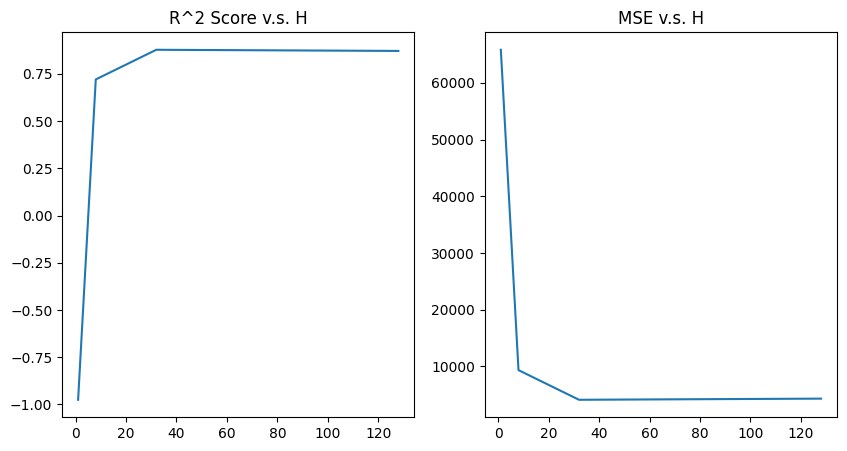

In [ ]:
#######################
# Dataset preparation #
#######################
def Q13_dataset_prep():
  # Read csv again and select features as Q10
  dataset = pd.read_csv("train.csv")[["hr", "yr", "workingday", "season", "atemp", "cnt"]]

  # One-hot encoding
  onehot_enc = OneHotEncoder(sparse_output=False)
  dataset[onehot_enc.get_feature_names_out(["hr"])] = onehot_enc.fit_transform(dataset[["hr"]])
  dataset[onehot_enc.get_feature_names_out(["season"])] = onehot_enc.fit_transform(dataset[["season"]])
  dataset = dataset.drop(columns=["hr", "season"])

  # Impute mean value if necessary
  dataset = pd.DataFrame(SimpleImputer().fit_transform(dataset), columns=dataset.columns)

  # Train test split
  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="cnt"), dataset["cnt"], test_size=0.2, random_state=4211)

  # Return
  return X_train, X_test, y_train, y_test

##########################
# Train and score models #
##########################
def Q13():
  # Get splited dataset
  X_train, X_test, y_train, y_test = Q13_dataset_prep()

  # Model container
  models = {}
  performances = {}

  # Train models of different hidden layer size
  for H in [1, 8, 32, 128]:
    # Train
    models[H] = MLPRegressor(hidden_layer_sizes=(H, ) * 3, early_stopping=True)
    models[H].fit(X_train, y_train)

    # Report
    performances[H] = [models[H].score(X_test, y_test), mean_squared_error(models[H].predict(X_test), y_test)]
    print(f"H={H}\nR^2 score: {performances[H][0]}\nMSE: {performances[H][1]}")
    print("-"*80)

  # Return
  return performances

########
# Plot #
########
def Q13_plot(H, r2, mse):
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))
  axs[0].set_title("R^2 Score v.s. H")
  axs[0].plot(H, r2)
  axs[1].set_title("MSE v.s. H")
  axs[1].plot(H, mse)

Q13_performances = Q13()
Q13_plot(Q13_performances.keys(), [p[0] for p in Q13_performances.values()], [p[1] for p in Q13_performances.values()])

###Q14: The Trend of Model Performance against Hidden Layer Size

From the graph in Q13, R<sup>2</sup> score increases whereas MSE decreases when the hidden layer size H increases.

When evaluating the regression models. the unitless R<sep>2</sep> score can be used to determine the ability to explain results while MSE, with the unit as the regression target, can measure the average squared error of the predictions.

###Q15: Hyperparameter: Activation Functions

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


H=1
R^2 score: 0.6624916235462321
MSE: 11251.554838874546
--------------------------------------------------------------------------------
H=8
R^2 score: 0.6627580905088861
MSE: 11242.671599665638
--------------------------------------------------------------------------------
H=32
R^2 score: 0.6609482148180269
MSE: 11303.007629844247
--------------------------------------------------------------------------------
H=128
R^2 score: 0.662754083377594
MSE: 11242.805185853787
--------------------------------------------------------------------------------


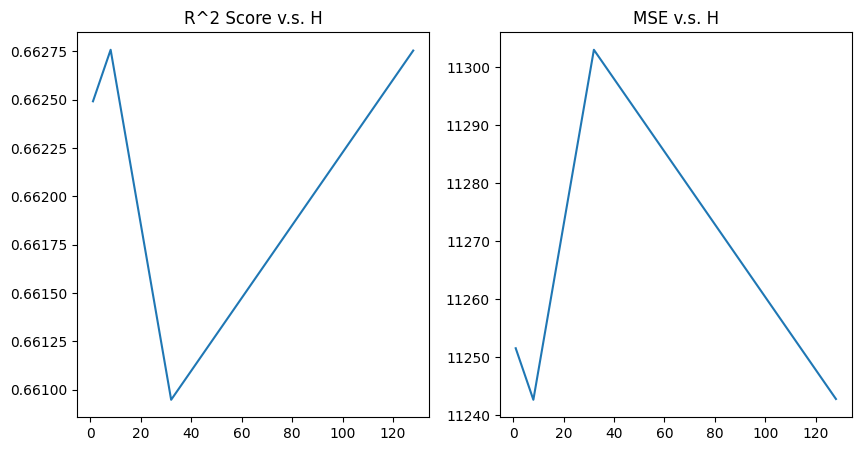

In [ ]:
##########################
# Train and score models #
##########################
def Q15():
  # Get splited dataset (same as Q13's dataset)
  X_train, X_test, y_train, y_test = Q13_dataset_prep()

  # Model container
  models = {}
  performances = {}

  # Train models of different hidden layer size
  for H in [1, 8, 32, 128]:
    # Train
    models[H] = MLPRegressor(hidden_layer_sizes=(H, ) * 3, early_stopping=True, activation="identity")
    models[H].fit(X_train, y_train)

    # Report
    performances[H] = [models[H].score(X_test, y_test), mean_squared_error(models[H].predict(X_test), y_test)]
    print(f"H={H}\nR^2 score: {performances[H][0]}\nMSE: {performances[H][1]}")
    print("-"*80)

  # Return
  return performances

Q15_performances = Q15()
Q13_plot(Q15_performances.keys(), [p[0] for p in Q15_performances.values()], [p[1] for p in Q15_performances.values()])

**Observation:**

When the activation function is changed from ReLU to identity function, the R<sep>2</sep> score and MSE among the new models are similar. Moreover, it is just slightly better than the linear regression model, which even uses less features.

This is because under identity function, the input vector **x**<sup>[0]</sup> multiply with the 1<sup>st</sup> weight matrix **W**<sup>[1]</sup>, and the intermediate vector **W**<sup>[1]</sup>**x**<sup>[0]</sup> directly multiply with the next weight matrix **W**<sup>[2]</sup>. The outcome **W**<sup>[2]</sup>**W**<sup>[1]</sup>**x**<sup>[0]</sup> can be represented in **U** **x**<sup>[0]</sup>, where **U** integrates the weight of 2 layers into 1 layer.

In short, using identity function will hide the effect of using hidden layers whereas ReLU, a non-linear function, can maintain the power of hidden layers.

##Part 4: Classification

###Q16: Logistic Regression

In [ ]:
#######################
# Dataset preparation #
#######################
def Q16_dataset_prep():
  # Read csv again and select features as Q10
  dataset = pd.read_csv("train.csv")[["hr", "season", "atemp", "weathersit", "hum", "uv"]]

  # Ordinal encoder
  dataset["weathersit"] = OrdinalEncoder(categories=[["Heavy Rain/Snow", "Light Snow/Rain", "Mist/Cloudy",  "Clear"]]).fit_transform(dataset[["weathersit"]])
  dataset["uv"] = OrdinalEncoder().fit_transform(dataset[["uv"]])

  # One-hot encoding
  onehot_enc = OneHotEncoder(sparse_output=False)
  dataset[onehot_enc.get_feature_names_out(["hr"])] = onehot_enc.fit_transform(dataset[["hr"]])
  dataset[onehot_enc.get_feature_names_out(["season"])] = onehot_enc.fit_transform(dataset[["season"]])
  dataset = dataset.drop(columns=["hr", "season"])

  # Impute mean value if necessary
  dataset = pd.DataFrame(SimpleImputer().fit_transform(dataset), columns=dataset.columns)

  # Train test split
  X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="uv"), dataset["uv"], test_size=0.2, random_state=4211)

  # Return
  return X_train, X_test, y_train, y_test

##########################
# Train and score models #
##########################
def Q16():
  # Get splited dataset
  X_train, X_test, y_train, y_test = Q16_dataset_prep()

  # Settings
  settings = [{"penalty": "l1"}, {"penalty": "l2"}, {"penalty": "l1", "alpha": 0.01}, {"penalty": "l2", "alpha": 0.01}]
  trials = 3

  # Train and score models of different settings
  last_model = None
  for setting in settings:
    # Statistics
    accuracy = np.zeros((trials,))
    f1 = np.zeros((trials,))
    time_lapsed = np.zeros((trials,))

    # Train
    for i in range(trials):
      model = SGDClassifier(loss="log_loss", eta0=0.01, verbose=0, random_state=4211, **setting)

      # Capture training time
      start_time = time.time()
      model.fit(X_train, y_train)
      end_time = time.time()

      # Predict
      res = model.predict(X_test)

      # Score
      accuracy[i] = accuracy_score(y_test, res)
      f1[i] = f1_score(y_test, res, average="micro")
      time_lapsed[i] = end_time - start_time

    # Report
    print(f"Parameters: {setting}:\n\t\t\tmean\t\t\t\tstd\n\taccuracy:\t{accuracy.mean()}\t\t{accuracy.std()}\n\tF1 score:\t{f1.mean()}\t\t{f1.std()}\n")
    last_model = model

  return last_model

Q16_last_model = Q16()

Parameters: {'penalty': 'l1'}:
			mean				std
	accuracy:	0.4203523912261777		5.551115123125783e-17
	F1 score:	0.4203523912261777		5.551115123125783e-17

Parameters: {'penalty': 'l2'}:
			mean				std
	accuracy:	0.3505933117583602		5.551115123125783e-17
	F1 score:	0.3505933117583602		5.551115123125783e-17

Parameters: {'penalty': 'l1', 'alpha': 0.01}:
			mean				std
	accuracy:	0.3268608414239482		0.0
	F1 score:	0.3268608414239482		0.0

Parameters: {'penalty': 'l2', 'alpha': 0.01}:
			mean				std
	accuracy:	0.40632865875584323		0.0
	F1 score:	0.40632865875584323		0.0



4 types of parameters are applied to the logistic regression model

For the first settings \(penalty="l1"\), the accuracy and the f1 score are around 0.42 \(with low std\)

For the second \(default\) settings \(penalty="l2\), the accuracy and the f1 score are around 0.35 \(with low std\)

For the third settings \(penalty="l1", alpha=0.01\), the accuracy and the f1 score are around 0.33 \(with very low std\)

For the fourth settings \(penalty="l2", alpha=0.01\), the accuracy and the f1 score are around 0.41 \(with very low std\)

###Q17: ROC curve and AUC value

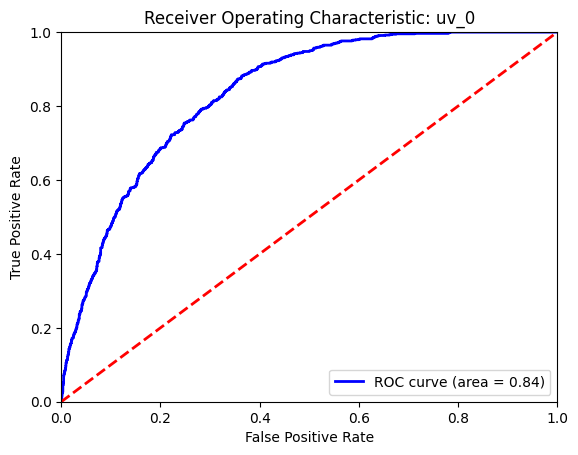

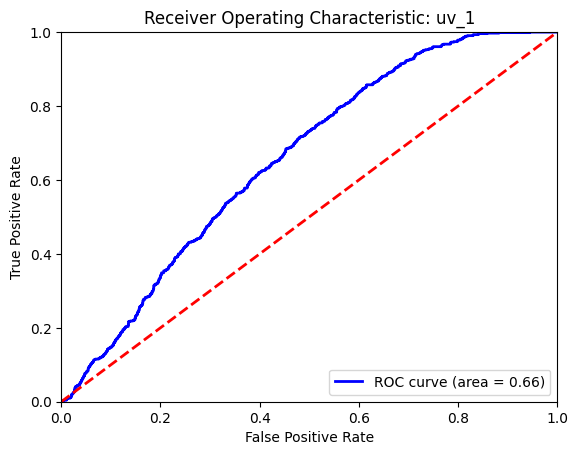

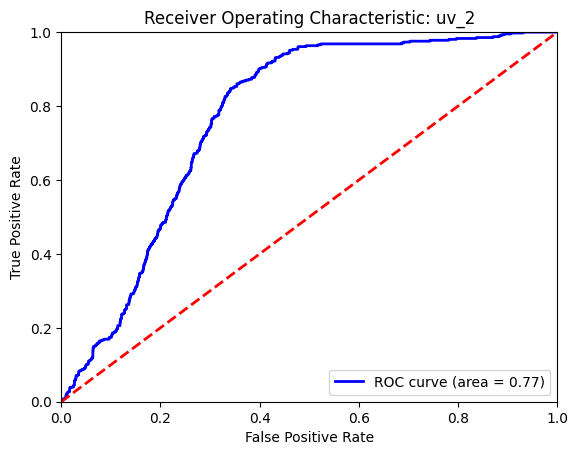

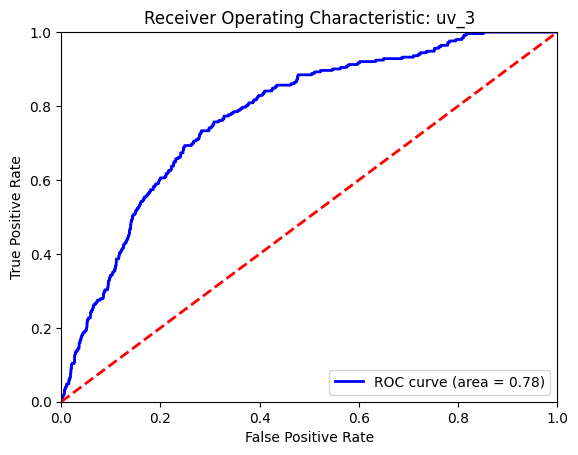

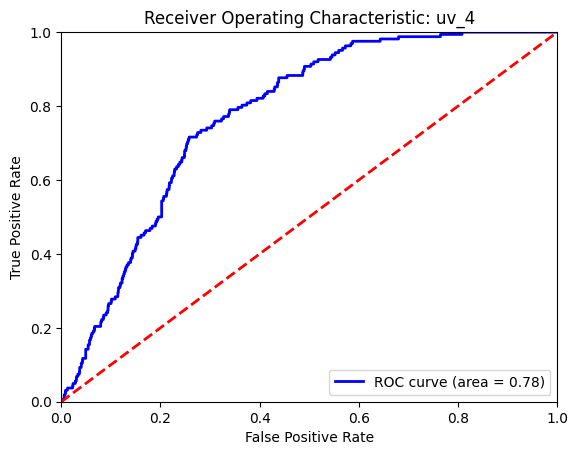

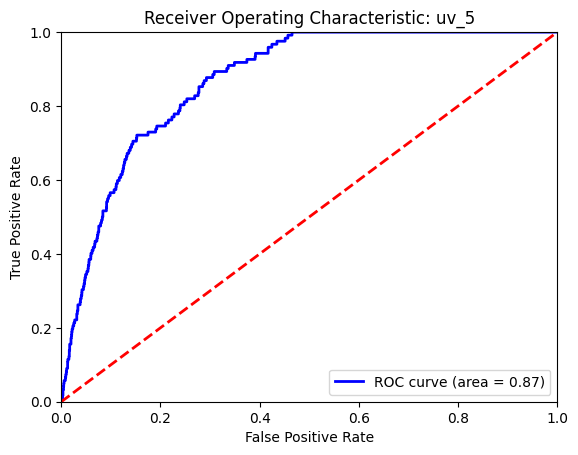

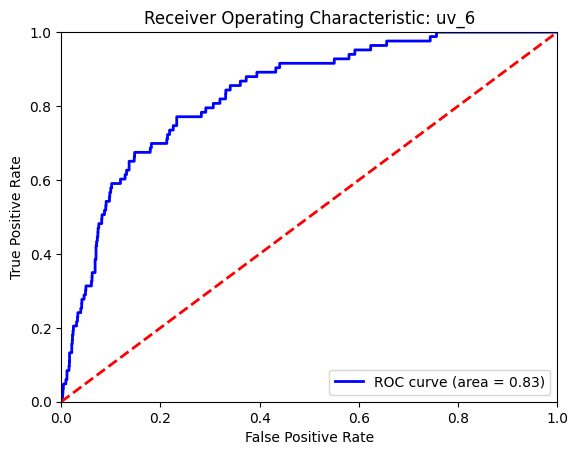

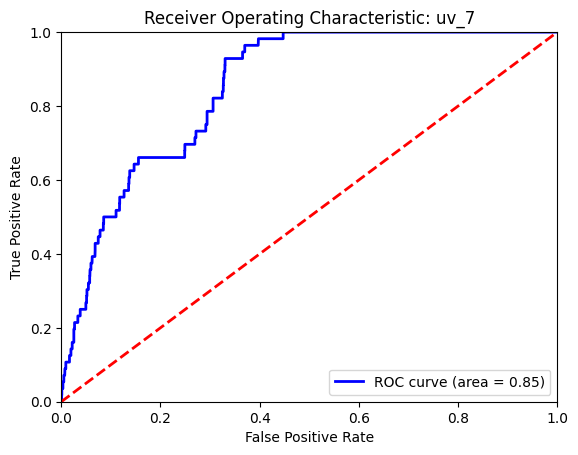

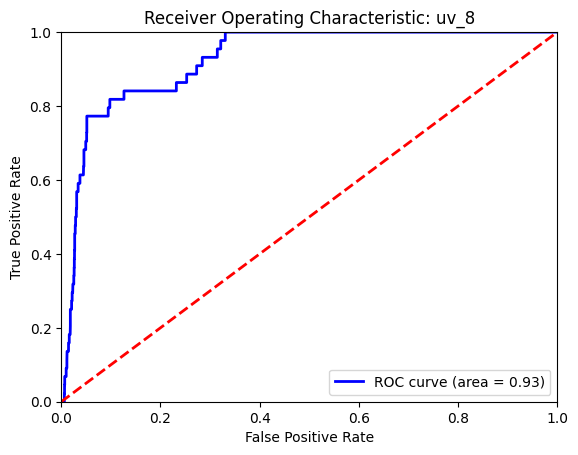

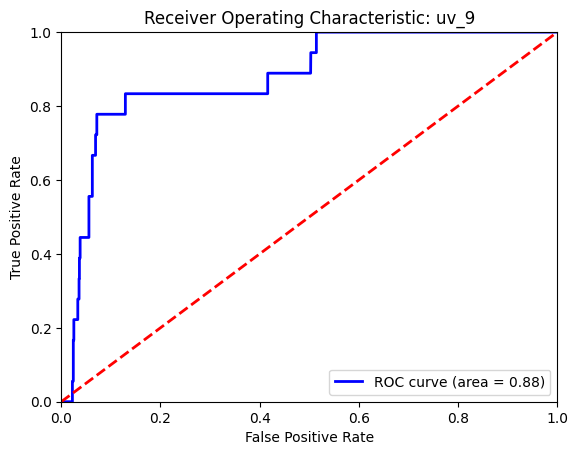

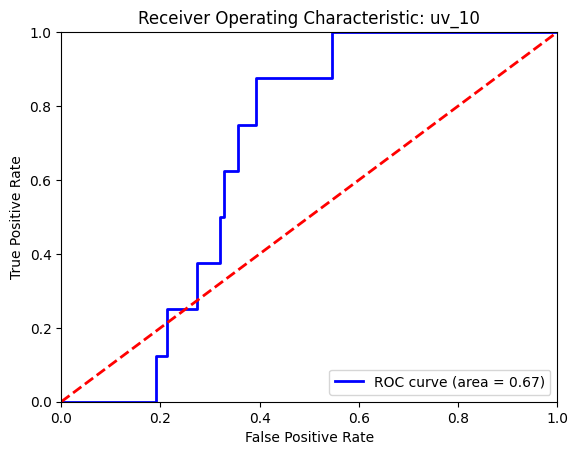

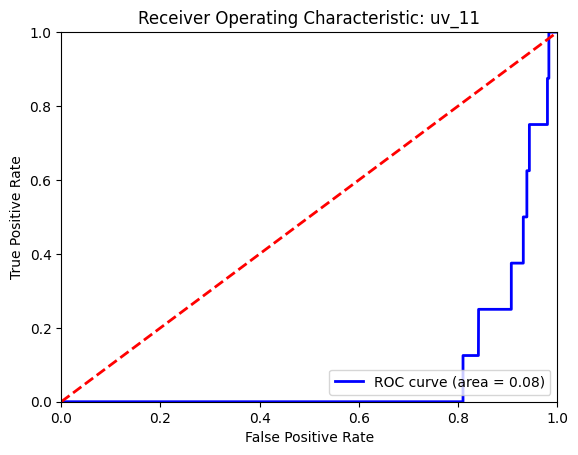

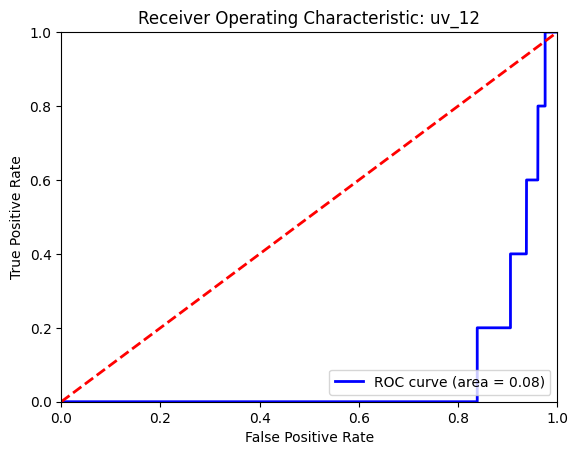

,AUC value
uv_0,0.836125
uv_1,0.656155
uv_2,0.769816
uv_3,0.777556
uv_4,0.776080
uv_5,0.870004
uv_6,0.834279
uv_7,0.850023
uv_8,0.926130
uv_9,0.878886


In [ ]:
########################################
# Plot ROC curves and report AUC value #
########################################
def report_roc_auc(model, X_test, y_test):
  auc_list = np.array([])
  for i in range(13):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, model.decision_function(X_test)[:,i], pos_label=i)

    # AUC value
    roc_auc = auc(fpr, tpr)
    auc_list = np.append(auc_list, roc_auc)

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Receiver Operating Characteristic: uv_{i}")
    plt.legend(loc="lower right")
    plt.show()

  # Report AUC values
  return pd.DataFrame(auc_list, index=[f"uv_{i}" for i in range(13)], columns=["AUC value"])

_, Q17_X_test, _, Q17_y_test = Q16_dataset_prep()
report_roc_auc(Q16_last_model, Q17_X_test, Q17_y_test)

###Q18: Confusion Matrix

<Axes: >

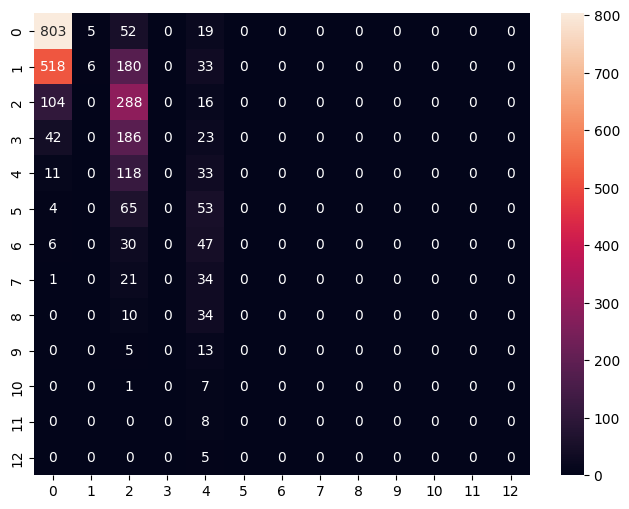

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(Q17_y_test, Q16_last_model.predict(Q17_X_test)), annot=True, fmt=".0f")

**Discussion:**

Confusion matrix can provide more details on the prediction than F1 score.

F1 score is a simple scalar that measure the performance of the model whereas confusion matrix can even look into the distribution of the prediction correctness. It is important since it shows 4 different kinds of prediction situations for further optimizations.

###Q19: Feedforward Neural Networks on Classification

In [ ]:
##########################
# Train and score models #
##########################
def Q19():
  # Get splited dataset (same as Q16's dataset)
  X_train, X_test, y_train, y_test = Q16_dataset_prep()

  # Model container
  models = {}
  performances = {}
  f1s = {}

  # Train models of different hidden layer size
  for H in [1, 8, 32, 128]:
    # Train
    models[H] = MLPClassifier(hidden_layer_sizes=(H, ) * 3, early_stopping=True)
    models[H].fit(X_train, y_train)

    # Predict
    res = models[H].predict(X_test)

    # Score
    accuracy = accuracy_score(y_test, res)
    f1_micro = f1_score(y_test, res, average="micro")
    f1_macro = f1_score(y_test, res, average="macro")
    f1s[H] = f1_micro
    performances[H] = [accuracy, f1_micro, f1_macro]

  # Return the best model
  return models, performances, max(f1s, key=f1s.get)

Q19_models, Q19_performances, Q19_best_model_index = Q19()

In [ ]:
# Q19 has the same dataset as Q17 (and Q16)
print(f"H of the best model: {Q19_best_model_index}")
print(f"Precision (micro):   {precision_score(Q17_y_test, Q19_models[Q19_best_model_index].predict(Q17_X_test), average='micro')}")
print(f"Recall (micro):      {recall_score(Q17_y_test, Q19_models[Q19_best_model_index].predict(Q17_X_test), average='micro')}")

H of the best model: 128
Precision (micro):   0.5771305285868392
Recall (micro):      0.5771305285868392


**Harmonic mean v.s. Arithmetic mean:**

F1 score is the harmonic mean of precision and recall, where precision is the ratio between true positive \(TP\) and those predicted positives \(TP + FP\), and recall is the ratio between true positive \(TP\) and those real positives \(TP + FN\).

As both the 2 scores are critical for evaluating the model's performance, to expose the weakness of a model more explicitly, harmonic mean is better in this case. Harmonic mean emphasizes low score due to the multiplication effect on its nominator.

###Q20: Report Model Settings and Performance

In [ ]:
# Report
def Q20_report_performances(performances):
  for H, p in performances.items():
    print(f"H={H}\nAccuracy: {p[0]}\nF1 score (micro): {p[1]}\nF1 score (macro): {p[2]}")
    print("-"*80)

Q20_report_performances(Q19_performances)

H=1
Accuracy: 0.2650125854009349
F1 score (micro): 0.2650125854009349
F1 score (macro): 0.03222985087680938
--------------------------------------------------------------------------------
H=8
Accuracy: 0.5634663790003596
F1 score (micro): 0.5634663790003596
F1 score (macro): 0.27702553877861974
--------------------------------------------------------------------------------
H=32
Accuracy: 0.5670622078389068
F1 score (micro): 0.5670622078389068
F1 score (macro): 0.3082243549978704
--------------------------------------------------------------------------------
H=128
Accuracy: 0.5771305285868392
F1 score (micro): 0.5771305285868392
F1 score (macro): 0.2888229443685864
--------------------------------------------------------------------------------


###Q21: Visualization of Model Performance

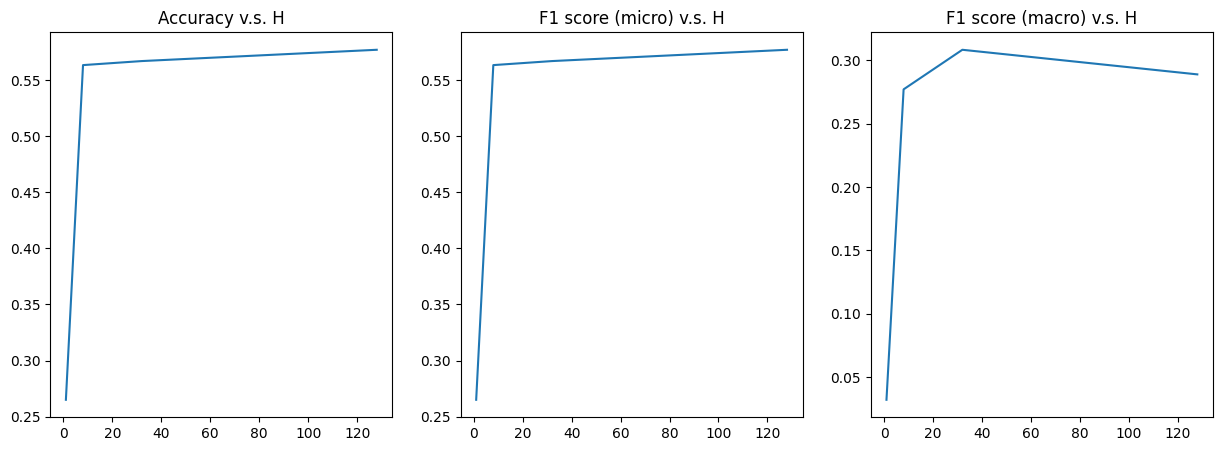

In [ ]:
########
# Plot #
########
def Q21_plot(performances):
  fig, axs = plt.subplots(1, 3, figsize=(15, 5))

  axs[0].set_title("Accuracy v.s. H")
  axs[1].set_title("F1 score (micro) v.s. H")
  axs[2].set_title("F1 score (macro) v.s. H")

  H = performances.keys()
  p = np.array(list(performances.values()))

  for i in range(3):
    axs[i].plot(H, p[:, i])

Q21_plot(Q19_performances)

**Comparison between macro and micro averages of F1 score:**

Macro and micro averages make differences in the formulae they used.

For a multiclass classification, there are several F1 scores with respect to a class. In this model, macro average will simply take an arithmetic mean among the respective F1 scores of the 13 UV index classes.

However, micro average first sum the confusion matrices to get a single aggregated matrix \(i.e. 1 TP, 1 TN, 1 FP and 1 FN only\) and perform the ordinary F1 score calculation.

**Scenarios of using different averaging method:**

Macro average gives equal weight to every class. Therefore, it is good at evaluating models using imbalanced dataset \(data sample for each class is not well distributed\).

Micro average gives a more aggregated view on the model performance. Therefore, unless the dataset is imbalanced, it is a more representable method.

**Possible reason for the gap between accuracy and macro F1 score:**

Accuracy implements micro average intrinsically, and by observation, the dataset has many samples for low UV index but not high UV index. Therefore, based on the discussion above, there could be a gap between the 2 values.

###Q22: The Trend of Model Performance against Hidden Layer Size

H=1
Accuracy: 0.27773781693939936
F1 score (micro): 0.27773781693939936
F1 score (macro): 0.03344105054048056
--------------------------------------------------------------------------------
H=8
Accuracy: 0.5591620212192052
F1 score (micro): 0.5591620212192052
F1 score (macro): 0.2733445507662875
--------------------------------------------------------------------------------
H=32
Accuracy: 0.5735479230354252
F1 score (micro): 0.5735479230354252
F1 score (macro): 0.30346025335650045
--------------------------------------------------------------------------------
H=128
Accuracy: 0.5739974824671822
F1 score (micro): 0.5739974824671822
F1 score (macro): 0.2967555060638494
--------------------------------------------------------------------------------


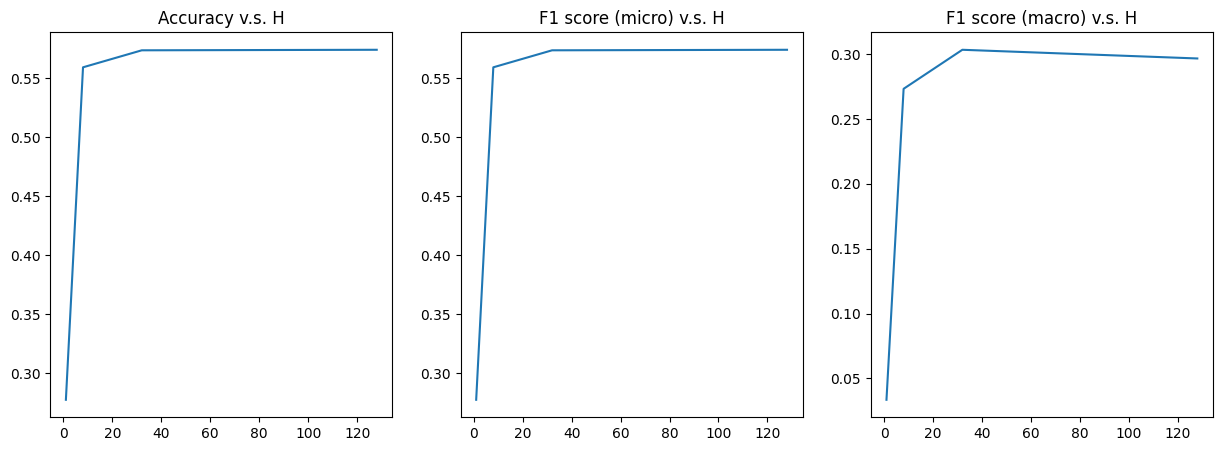

In [ ]:
#############################
# Observe training accuracy #
#############################
def Q22(trained_models):
  # Get splited dataset (the same as Q21's dataset)
  X_train, X_test, y_train, y_test = Q16_dataset_prep()

  performances = {}

  # Predict on training dataset
  for H, model in trained_models.items():
    res = model.predict(X_train)

    # Score
    accuracy = accuracy_score(y_train, res)
    f1_micro = f1_score(y_train, res, average="micro")
    f1_macro = f1_score(y_train, res, average="macro")
    performances[H] = [accuracy, f1_micro, f1_macro]

  return performances

Q22_performances = Q22(Q19_models)

Q21_plot(Q22_performances)
Q20_report_performances(Q22_performances)


**Performance trend:**

Recall the accuracy and the F1 scores recorded in Q21, the accuracy and F1 score \(micro\) increased when H increased to 8, and they remained stable when H further increased. However, for F1 score \(macro\), it further increased after H changed from 8 to 32 / 128.

**Reasons:**

When H=1, there are too few learnable weights, causing underfitting, and the activation state of the only neuron in each layer totally determine the output, resulting a rough prediction.

When H=8/32, the above problems are solved.

When H=128, the result is unstable. Sometimes the F1 score \(macro\) will reduce due to overfitting, but some other trials may improve the recall and precision on classes with very few data samples, resulting an improvement of F1 score \(macro\) since it reflects improvement on those classes.

###Q23: ROC Curve

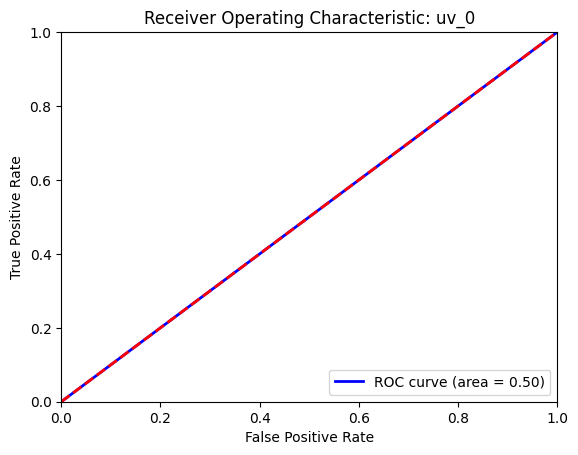

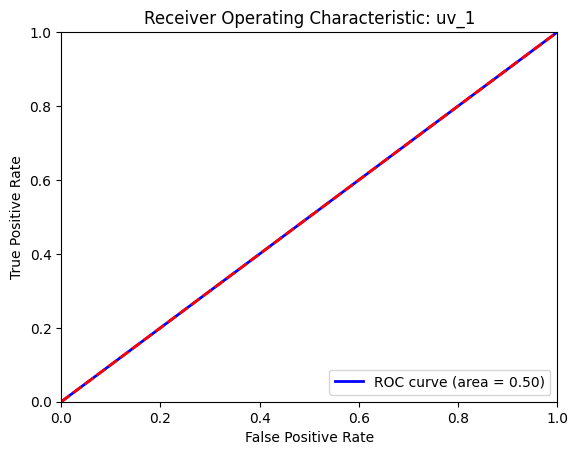

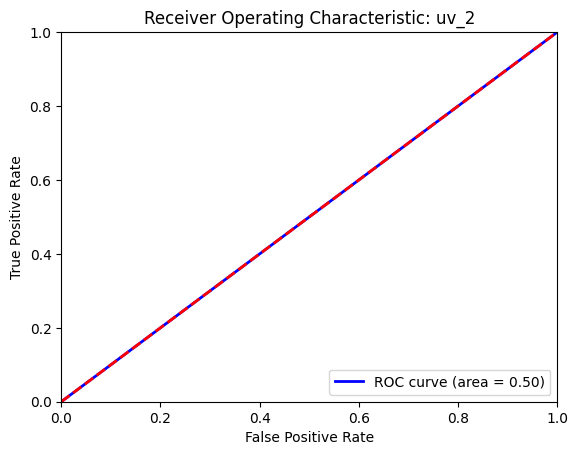

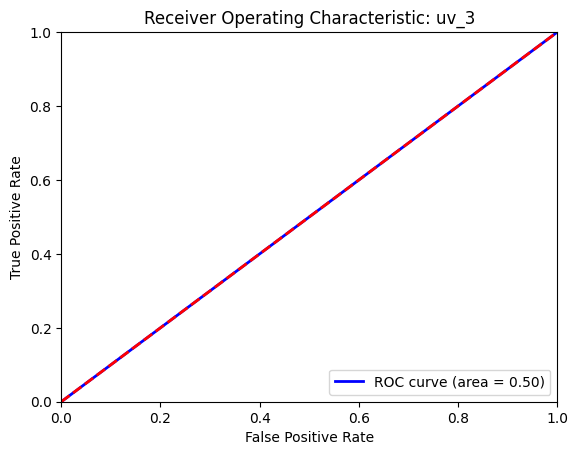

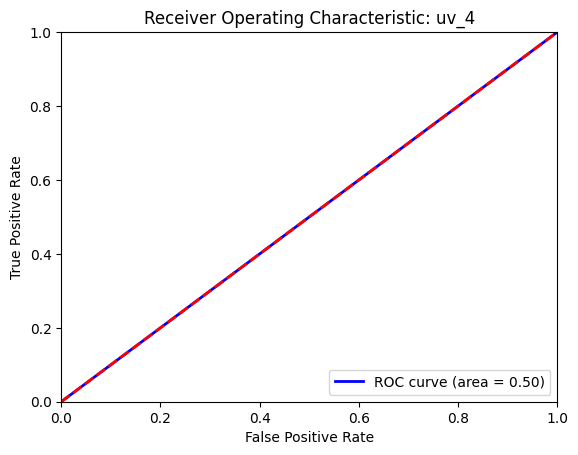

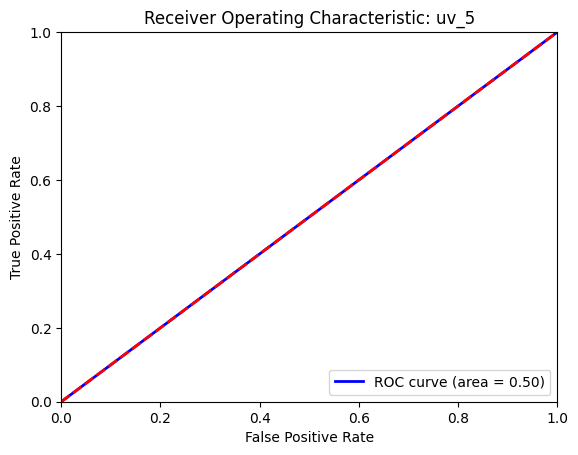

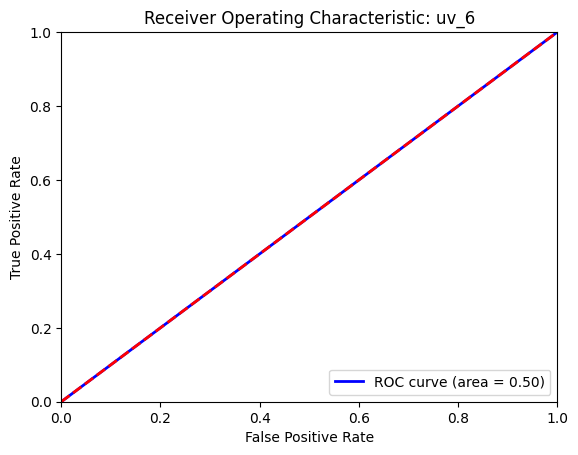

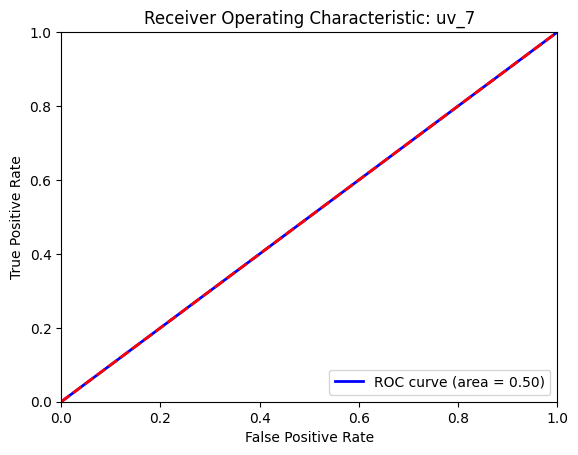

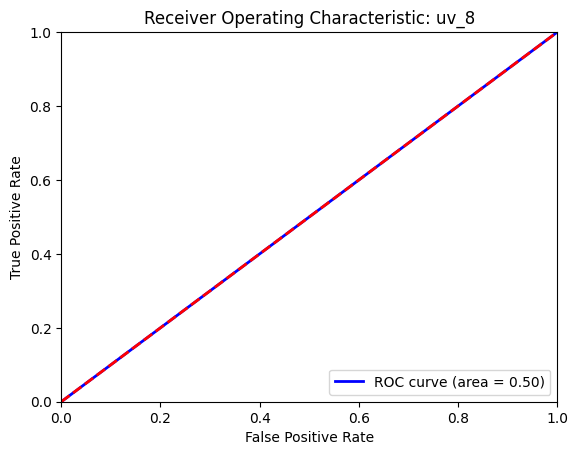

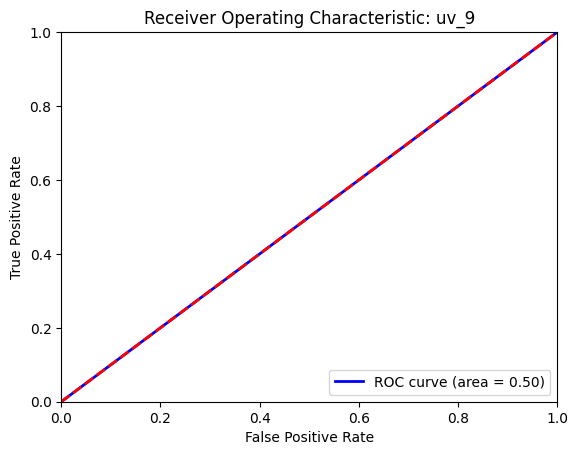

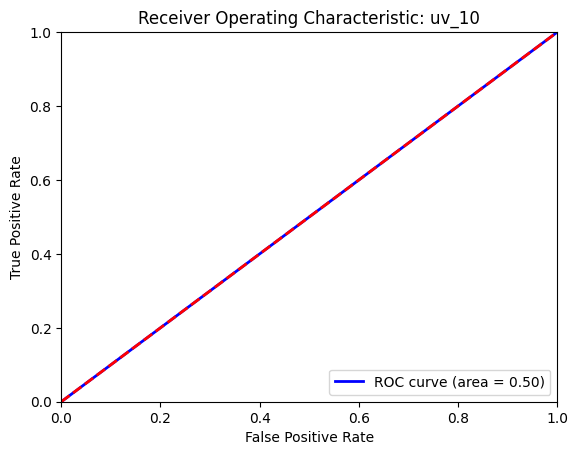

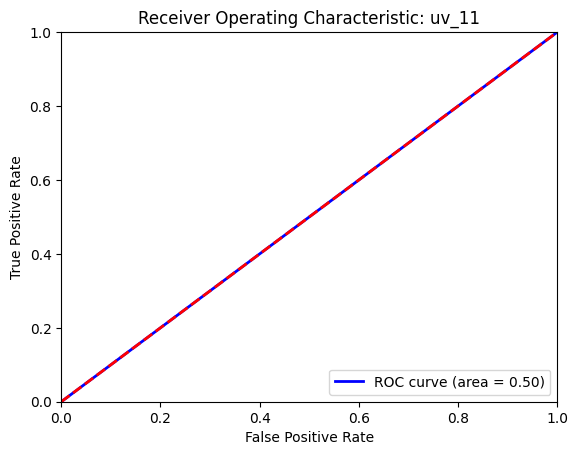

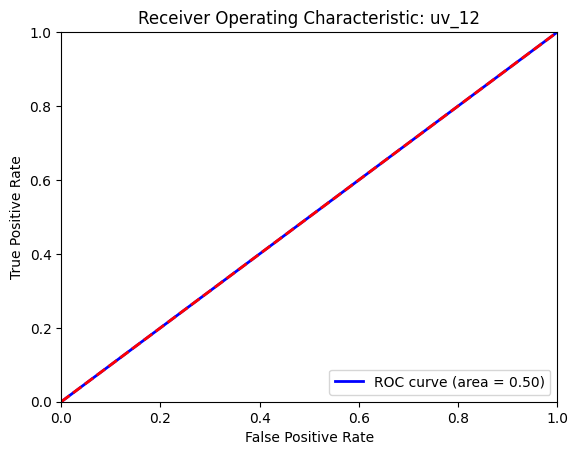

,AUC value
uv_0,0.5
uv_1,0.5
uv_2,0.5
uv_3,0.5
uv_4,0.5
uv_5,0.5
uv_6,0.5
uv_7,0.5
uv_8,0.5
uv_9,0.5


In [ ]:
########################################
# Plot ROC curves and report AUC value #
########################################
def report_roc_auc_fnn(model, X_test, y_test):
  auc_list = np.array([])
  for i in range(13):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,i], pos_label=i)

    # AUC value
    roc_auc = auc(fpr, tpr)
    auc_list = np.append(auc_list, roc_auc)

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Receiver Operating Characteristic: uv_{i}")
    plt.legend(loc="lower right")
    plt.show()

  # Report AUC values
  return pd.DataFrame(auc_list, index=[f"uv_{i}" for i in range(13)], columns=["AUC value"])

# H=1
_, Q17_X_test, _, Q17_y_test = Q16_dataset_prep()
report_roc_auc_fnn(Q19_models[1], Q17_X_test, Q17_y_test)

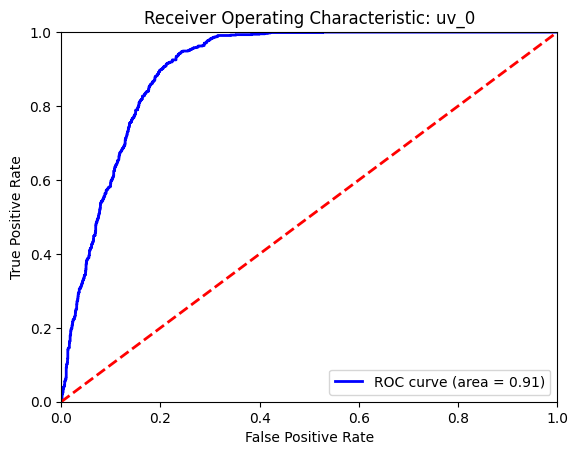

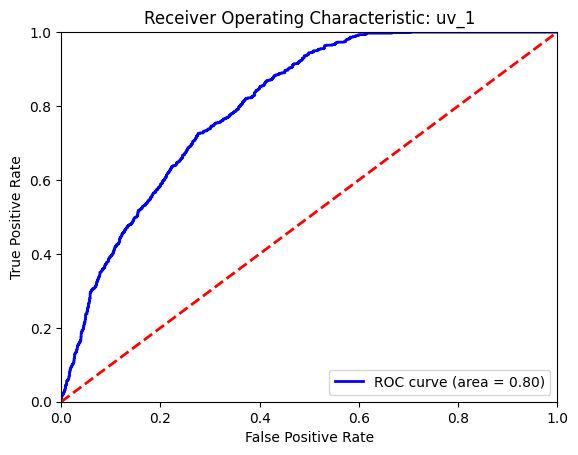

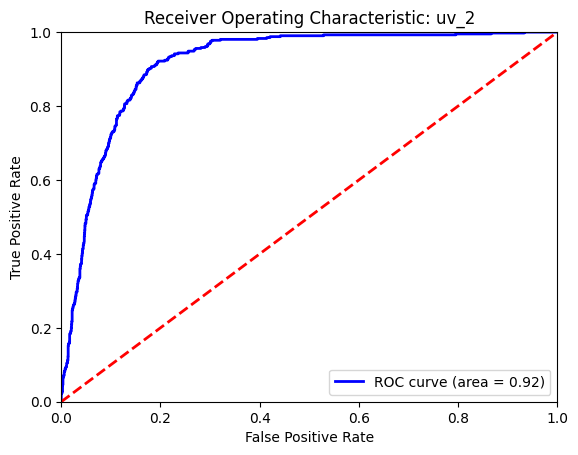

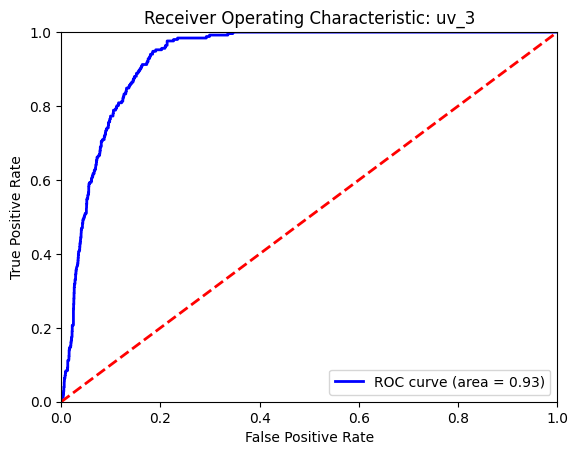

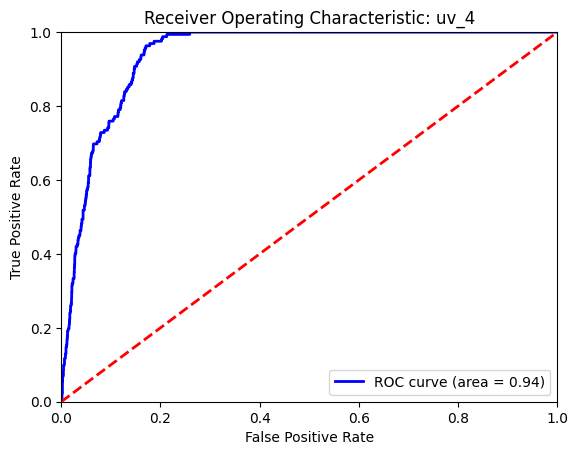

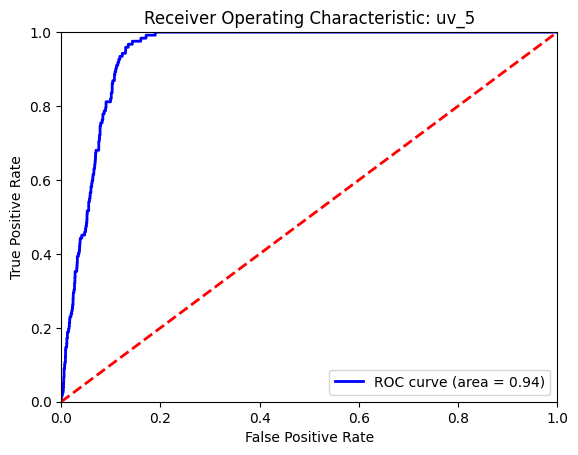

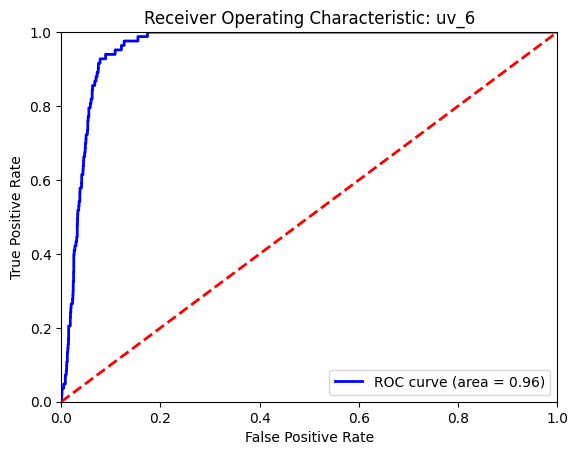

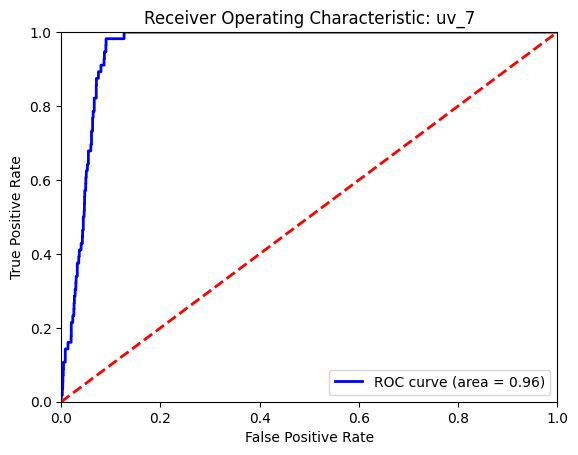

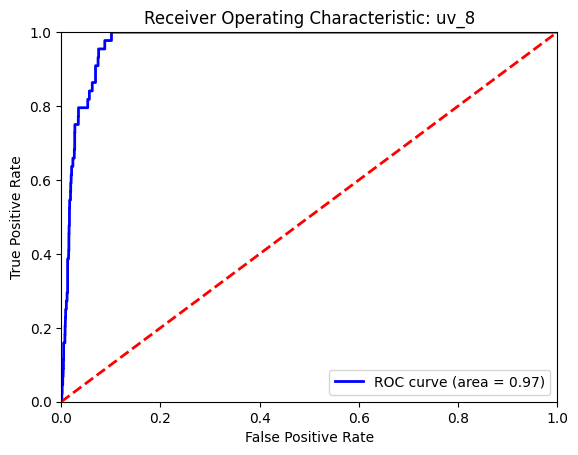

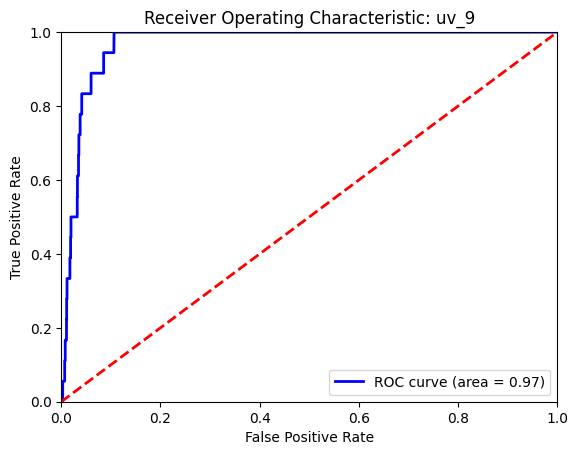

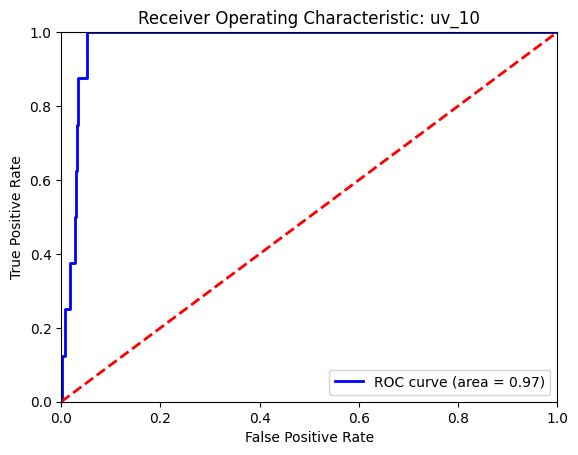

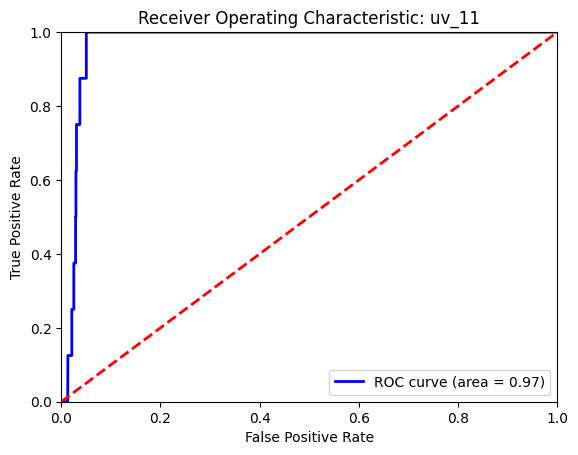

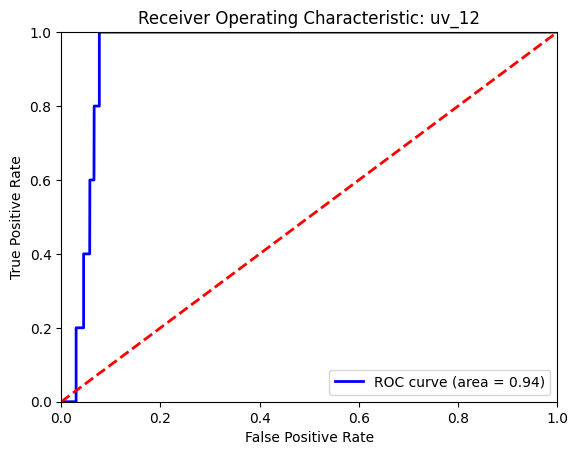

,AUC value
uv_0,0.905025
uv_1,0.804245
uv_2,0.915558
uv_3,0.931303
uv_4,0.938801
uv_5,0.944480
uv_6,0.958928
uv_7,0.955455
uv_8,0.973478
uv_9,0.968201


In [ ]:
# H=128
report_roc_auc_fnn(Q19_models[Q19_best_model_index], Q17_X_test, Q17_y_test)

**Benefit of examining ROC curves:**

ROC curve \(with AUC value\) is another metric measuring the model performance. The curve is computed by adjusting the threshold of output decision and inspecting the true positive rate \(TPR\) and false positive rate \(FPR\).

Theoretically, a perfect model has a 100% TPR everywhere, and the AUC value = 1.

Inspecting ROC curve can provide a more macroscopic view than F1 score. The reason is ROC curve include threshold to illustrate the trade-off between specificity and the opposite.

In multiclass classification problem, it can have better description on different classes than F1 score, especially when the classification is imbalanced.

##Part 5: Bonus

###B3: More on Feature Engineering

###B4: Hyperparameter Tuning

###B5: Model Selection

###B6: Prediction